### Additional Dataset

An additional labeled dataset was used to supplement the competition training data:

**Airline Passenger Satisfaction**

Source: Kaggle — teejmahal20
https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction

## Imports

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from itertools import product

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier

sns.set_style('whitegrid')

## Data Loading and Distribution Analysis

Competition train
Shape: (699635, 23)

Columns:
['id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

Missing values:
Arrival Delay in Minutes    292
dtype: int64

Competition test
Shape: (299844, 22)

Columns:
['id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender', 'Customer Type', 'Type o

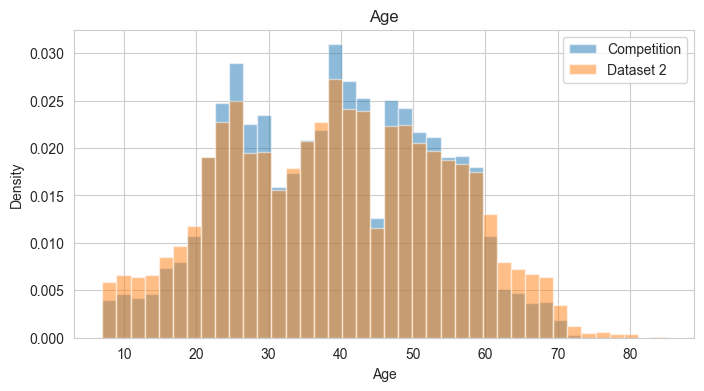

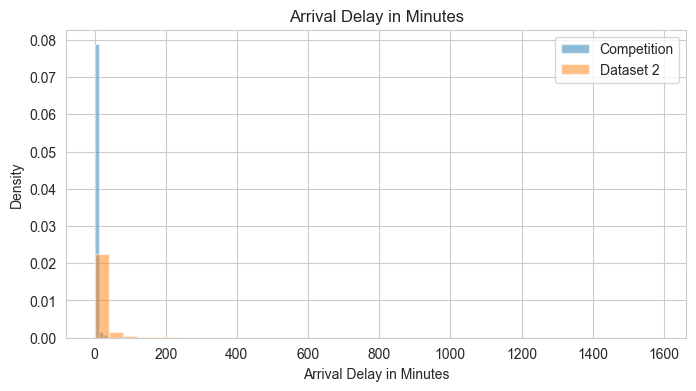

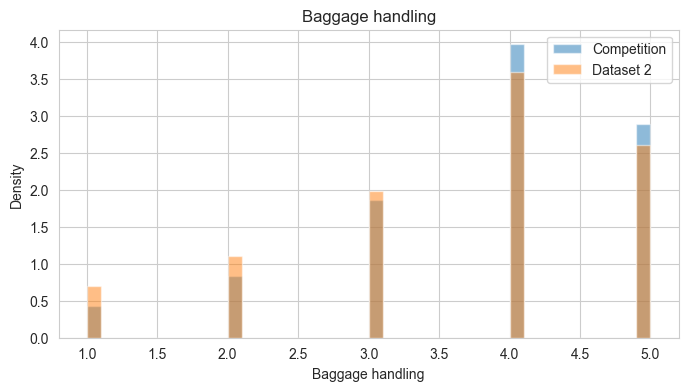

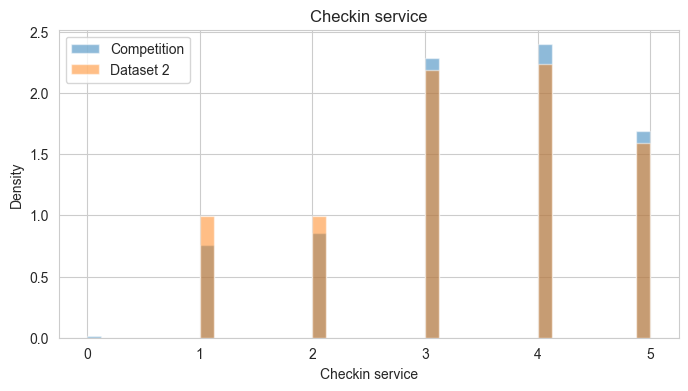

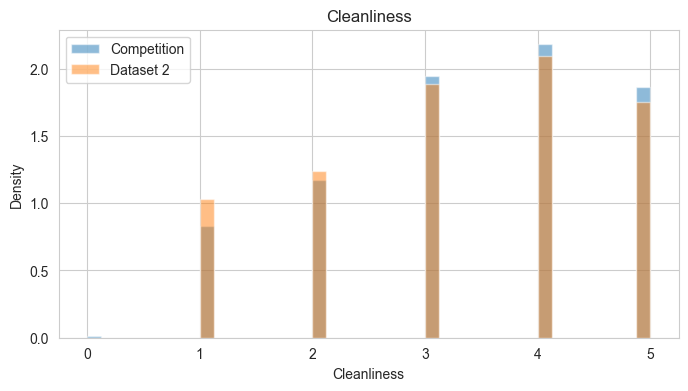

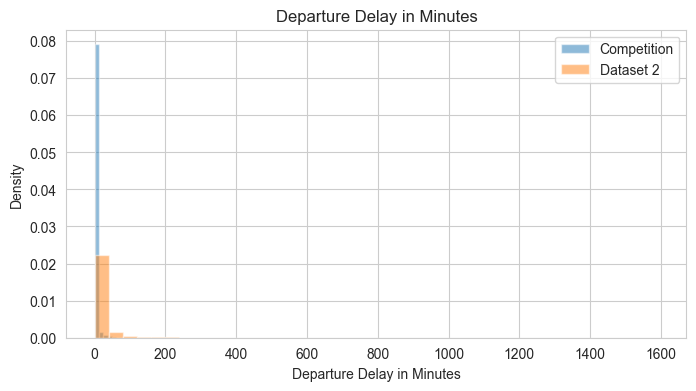

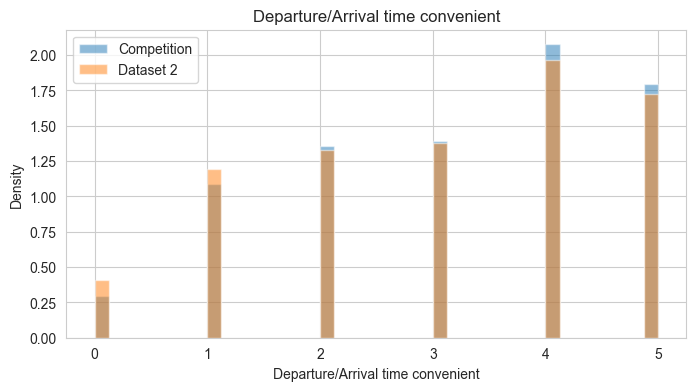

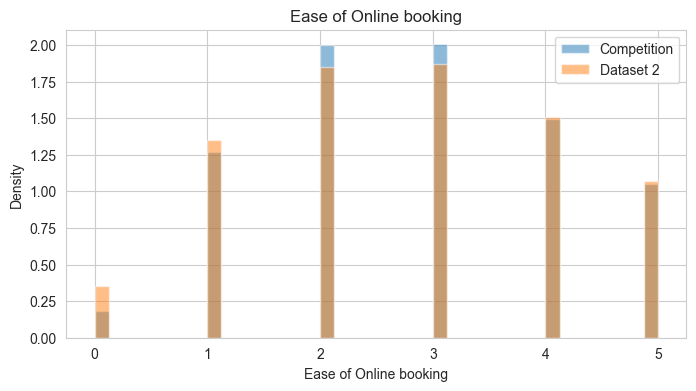

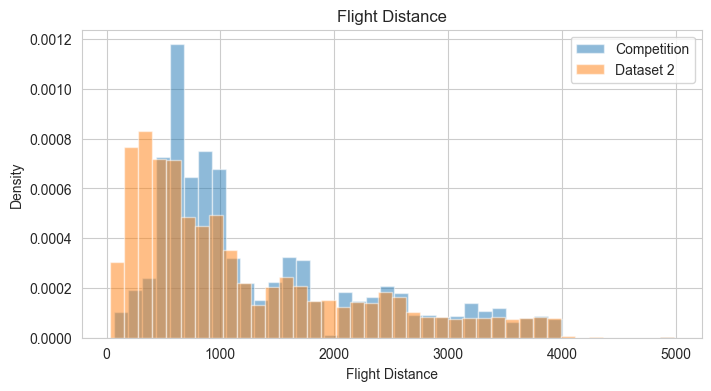

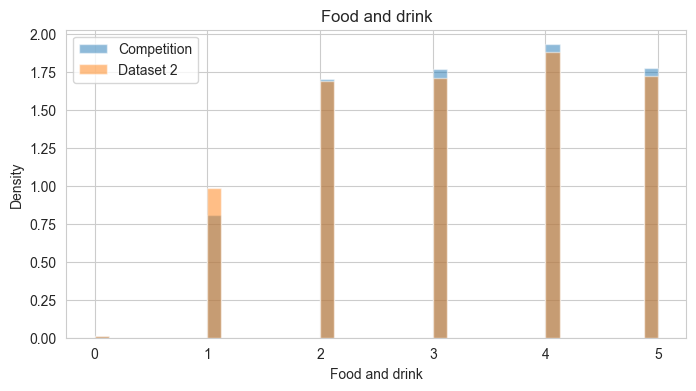

In [88]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
dataset2_train = pd.read_csv("archive-7/train.csv")
dataset2_test = pd.read_csv("archive-7/test.csv")
dataset2 = pd.concat(
    [dataset2_train, dataset2_test],
    ignore_index=True
)

datasets = {
    "Competition train": train,
    "Competition test": test,
    "Dataset 2": dataset2
}

for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing values:")
    print(df.isna().sum()[df.isna().sum() > 0])
    print()

def compare_columns(df1, df2, name1, name2):
    cols1 = set(df1.columns)
    cols2 = set(df2.columns)
    common = sorted(cols1 & cols2)
    only1 = sorted(cols1 - cols2)
    only2 = sorted(cols2 - cols1)
    print("=" * 70)
    print(f"{name1} vs {name2}")
    print("=" * 70)
    print(f"\nОбщих колонок: {len(common)}")
    print(common)
    print(f"\nТолько в {name1}:")
    print(only1)
    print(f"\nТолько в {name2}:")
    print(only2)
    print()

compare_columns(
    train,
    dataset2,
    "Competition",
    "Dataset 2"
)

print("=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)

for name, df in {
    "Competition": train,
    "Dataset 2": dataset2
}.items():
    if "satisfaction" in df.columns:
        print(f"\n{name}")
        print(
            df["satisfaction"]
            .value_counts(
                normalize=True,
                dropna=False
            )
            .round(4)
        )

def compare_numeric(df1, df2, name1, name2):
    ignore = {
        "id",
        "satisfaction",
        "Unnamed: 0"
    }
    common = set(df1.columns) & set(df2.columns)
    numeric_cols = []
    for col in common:
        if col in ignore:
            continue
        if (
            pd.api.types.is_numeric_dtype(df1[col])
            and
            pd.api.types.is_numeric_dtype(df2[col])
        ):
            numeric_cols.append(col)
    results = []
    for col in numeric_cols:
        x1 = df1[col].dropna()
        x2 = df2[col].dropna()
        if len(x1) == 0 or len(x2) == 0:
            continue
        ks = ks_2samp(x1, x2).statistic
        results.append({
            "feature": col,
            f"{name1}_mean": x1.mean(),
            f"{name2}_mean": x2.mean(),
            f"{name1}_std": x1.std(),
            f"{name2}_std": x2.std(),
            "KS": ks
        })
    result = pd.DataFrame(results)
    if len(result) > 0:
        result = result.sort_values(
            "KS",
            ascending=False
        )
    return result

print("\n" + "=" * 70)
print("COMPETITION vs DATASET 2 — NUMERIC")
print("=" * 70)

ks_dataset2 = compare_numeric(
    train,
    dataset2,
    "Competition",
    "Dataset2"
)

print(
    ks_dataset2
    .round(4)
    .to_string(index=False)
)

def compare_categories(df1, df2, name1, name2):
    ignore = {
        "id",
        "satisfaction",
        "Unnamed: 0"
    }
    common = set(df1.columns) & set(df2.columns)
    categorical_cols = []
    for col in common:
        if col in ignore:
            continue
        if (
            not pd.api.types.is_numeric_dtype(df1[col])
            or
            not pd.api.types.is_numeric_dtype(df2[col])
        ):
            categorical_cols.append(col)
    for col in sorted(categorical_cols):
        print("\n" + "-" * 70)
        print(col)
        print("-" * 70)
        dist1 = df1[col].value_counts(
            normalize=True,
            dropna=False
        )
        dist2 = df2[col].value_counts(
            normalize=True,
            dropna=False
        )
        comparison = pd.concat(
            [dist1, dist2],
            axis=1
        ).fillna(0)
        comparison.columns = [
            name1,
            name2
        ]
        print(comparison.round(4))

print("\n" + "=" * 70)
print("COMPETITION vs DATASET 2 — CATEGORICAL")
print("=" * 70)

compare_categories(
    train,
    dataset2,
    "Competition",
    "Dataset2"
)

def plot_numeric_distributions(
    df1,
    df2,
    name1,
    name2,
    max_features=10
):
    ignore = {
        "id",
        "satisfaction",
        "Unnamed: 0"
    }
    common = set(df1.columns) & set(df2.columns)
    numeric_cols = []
    for col in common:
        if col in ignore:
            continue
        if (
            pd.api.types.is_numeric_dtype(df1[col])
            and
            pd.api.types.is_numeric_dtype(df2[col])
        ):
            numeric_cols.append(col)
    for col in sorted(numeric_cols)[:max_features]:
        plt.figure(figsize=(8, 4))
        plt.hist(
            df1[col].dropna(),
            bins=40,
            density=True,
            alpha=0.5,
            label=name1
        )
        plt.hist(
            df2[col].dropna(),
            bins=40,
            density=True,
            alpha=0.5,
            label=name2
        )
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.show()

plot_numeric_distributions(
    train,
    dataset2,
    "Competition",
    "Dataset 2"
)

 ## Data Preparation

In [89]:
dataset2 = dataset2.drop(
    columns = [
        "Unnamed: 0",
        "Inflight service"
    ]
)
dataset2["satisfaction"] = dataset2["satisfaction"].map({
    "neutral or dissatisfied": False,
    "satisfied": True
})
dataset2 = dataset2[train.columns]

print("Competition train:", train.shape)
print("Dataset 2:", dataset2.shape)
print("\nCompetition columns:")
print(train.columns.tolist())
print("\nDataset 2 columns:")
print(dataset2.columns.tolist())
print("\nSame columns:")
print(train.columns.tolist() == dataset2.columns.tolist())
print("\nDataset 2 target:")
print(dataset2["satisfaction"].value_counts())

Competition train: (699635, 23)
Dataset 2: (129880, 23)

Competition columns:
['id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

Dataset 2 columns:
['id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

Same columns:
True

Dat

## Data Info

In [90]:
print("Train shape:", train.shape)
print("Dataset2 shape:", dataset2.shape)
print("Test shape:", test.shape)

Train shape: (699635, 23)
Dataset2 shape: (129880, 23)
Test shape: (299844, 22)


### Train

In [91]:
dfinfo = pd.DataFrame({
    'dtypes': train.dtypes,
    'count': train.count(),
    'nunique': train.nunique(),
    'missing': train.isnull().sum(),
})
dfinfo

,dtypes,count,nunique,missing
id,int64,699635,699635,0
Age,int64,699635,75,0
Flight Distance,int64,699635,3474,0
Inflight wifi service,int64,699635,6,0
Departure/Arrival time convenient,int64,699635,6,0
Ease of Online booking,int64,699635,6,0
Gate location,int64,699635,6,0
Food and drink,int64,699635,6,0
Online boarding,int64,699635,6,0
Seat comfort,int64,699635,6,0


### Dataset2

In [92]:
dfinfo2 = pd.DataFrame({
    'dtypes': dataset2.dtypes,
    'count': dataset2.count(),
    'nunique': dataset2.nunique(),
    'missing': dataset2.isnull().sum(),
})
dfinfo2

,dtypes,count,nunique,missing
id,int64,129880,129880,0
Age,int64,129880,75,0
Flight Distance,int64,129880,3821,0
Inflight wifi service,int64,129880,6,0
Departure/Arrival time convenient,int64,129880,6,0
Ease of Online booking,int64,129880,6,0
Gate location,int64,129880,6,0
Food and drink,int64,129880,6,0
Online boarding,int64,129880,6,0
Seat comfort,int64,129880,6,0


### Test

In [93]:
dfinfo3 = pd.DataFrame({
    'dtypes': test.dtypes,
    'count': test.count(),
    'nunique': test.nunique(),
    'missing': test.isnull().sum(),
})
dfinfo3

,dtypes,count,nunique,missing
id,int64,299844,299844,0
Age,int64,299844,75,0
Flight Distance,int64,299844,3317,0
Inflight wifi service,int64,299844,6,0
Departure/Arrival time convenient,int64,299844,6,0
Ease of Online booking,int64,299844,6,0
Gate location,int64,299844,6,0
Food and drink,int64,299844,6,0
Online boarding,int64,299844,6,0
Seat comfort,int64,299844,6,0


In [94]:
categorical_features = train.select_dtypes(include = "object").columns.tolist()
numerical_features = train.select_dtypes(include = np.number).columns.tolist()
numerical_features.remove("id")

print("Categorical features:")
print(categorical_features)
print("\nNumerical features:")
print(numerical_features)
print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Categorical features:
['Gender', 'Customer Type', 'Type of Travel', 'Class']

Numerical features:
['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Number of categorical features: 4
Number of numerical features: 17


## OOF loop

In [95]:
def run_cv(model_func, X, y, X_test, X_extra=None, y_extra=None, n_folds=5, model_name='Model'):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    auc_scores = []
    for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
        print(f'{model_name}, Fold {fold + 1}/{n_folds}')
        X_tr, X_val = X.iloc[train_index], X.iloc[val_index]
        y_tr, y_val = y.iloc[train_index], y.iloc[val_index]
        if X_extra is not None:
            X_tr = pd.concat([X_tr, X_extra], ignore_index=True)
            y_tr = pd.concat([y_tr, y_extra], ignore_index=True)
        model = model_func(fold, X_tr, y_tr, X_val, y_val)
        oof_preds[val_index] = model.predict_proba(X_val)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / n_folds
        fold_auc = roc_auc_score(y_val, oof_preds[val_index])
        auc_scores.append(fold_auc)
        print(f'AUC Fold {fold + 1}: {fold_auc:.5f}')
    oof_auc = roc_auc_score(y, oof_preds)
    print(f'\n{model_name} OOF AUC: {oof_auc:.5f} | '
          f'Mean fold AUC: {np.mean(auc_scores):.5f} +/- {np.std(auc_scores):.5f}')
    return oof_preds, test_preds, oof_auc

# LightGBM Baseline

## Preparing

In [96]:
drop_cols = ['id', 'satisfaction']
feature_cols = [c for c in train.columns if c not in drop_cols]

X_baseline = train[feature_cols].reset_index(drop=True)
y_baseline = train['satisfaction'].reset_index(drop=True)

X_dataset2 = dataset2[feature_cols].reset_index(drop=True)
y_dataset2 = dataset2['satisfaction'].reset_index(drop=True)

X_test = test[feature_cols].reset_index(drop=True)

X_baseline[categorical_features] = X_baseline[categorical_features].astype("category")
X_dataset2[categorical_features] = X_dataset2[categorical_features].astype("category")
X_test[categorical_features] = X_test[categorical_features].astype("category")

In [97]:
X_lgb = X_baseline.copy()
X_dataset2_lgb = X_dataset2.copy()
X_test_lgb = X_test.copy()

for col in categorical_features:
    X_lgb[col] = X_lgb[col].astype('category')
    X_dataset2_lgb[col] = X_dataset2_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

def objective_lgb(trial):
    params = {
        'n_estimators': 2000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective': 'binary',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1,
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    for train_index, val_index in skf.split(X_lgb, y_baseline):
        X_tr, X_val = X_lgb.iloc[train_index], X_lgb.iloc[val_index]
        y_tr, y_val = y_baseline.iloc[train_index], y_baseline.iloc[val_index]
        model = LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric='auc',
            categorical_feature=categorical_features,
            callbacks=[
                early_stopping(stopping_rounds=100, verbose=False)
            ]
        )
        pred = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, pred))
    return np.mean(auc_scores)

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=30)

print('Best AUC:', study_lgb.best_value)
print('Best params:')
print(study_lgb.best_params)

def lgb_model_func(fold, X_tr, y_tr, X_val, y_val):
    params = study_lgb.best_params.copy()
    model = LGBMClassifier(
        **params,
        n_estimators=2000,
        objective='binary',
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        categorical_feature=categorical_features,
        callbacks=[
            early_stopping(stopping_rounds=150),
            log_evaluation(period=200)
        ]
    )
    return model

oof_lgb, test_lgb, auc_lgb = run_cv(
    lgb_model_func,
    X_lgb,
    y_baseline,
    X_test_lgb,
    n_folds=5,
    model_name='LightGBM'
)

oof_lgb_ext, test_lgb_ext, auc_lgb_ext = run_cv(
    lgb_model_func,
    X_lgb,
    y_baseline,
    X_test_lgb,
    X_extra=X_dataset2_lgb,
    y_extra=y_dataset2,
    n_folds=5,
    model_name='LightGBM + Dataset 2'
)

print(f'\nLightGBM:             {auc_lgb:.5f}')
print(f'LightGBM + Dataset 2: {auc_lgb_ext:.5f}')
print(f'Difference:           {auc_lgb_ext - auc_lgb:+.5f}')

[I 2026-10-06 11:37:39,295] A new study created in memory with name: no-name-21e6057b-fc39-43e4-81a4-30c74e1f9de0
[I 2026-10-06 11:38:48,696] Trial 0 finished with value: 0.9578929549306597 and parameters: {'learning_rate': 0.029195813143242877, 'num_leaves': 75, 'max_depth': 4, 'min_child_samples': 99, 'subsample': 0.9475179715522931, 'colsample_bytree': 0.8834164769601728, 'reg_alpha': 7.016995950620469e-08, 'reg_lambda': 1.3245147949090661e-05}. Best is trial 0 with value: 0.9578929549306597.
[I 2026-10-06 11:40:35,008] Trial 1 finished with value: 0.9580948560953173 and parameters: {'learning_rate': 0.01060212862431761, 'num_leaves': 31, 'max_depth': 6, 'min_child_samples': 54, 'subsample': 0.6861246355082727, 'colsample_bytree': 0.7113400525946855, 'reg_alpha': 0.0003427522255556343, 'reg_lambda': 1.1645792053707878e-08}. Best is trial 1 with value: 0.9580948560953173.
[I 2026-10-06 11:42:01,264] Trial 2 finished with value: 0.9587620393604706 and parameters: {'learning_rate': 0.0

Best AUC: 0.9588441100031982
Best params:
{'learning_rate': 0.018907058242758065, 'num_leaves': 103, 'max_depth': 10, 'min_child_samples': 57, 'subsample': 0.9845275906755203, 'colsample_bytree': 0.6858899687291645, 'reg_alpha': 2.1345778610950447e-07, 'reg_lambda': 4.218857080351551e-06}
LightGBM, Fold 1/5
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc: 0.957098	valid_0's binary_logloss: 0.234657
[400]	valid_0's auc: 0.958628	valid_0's binary_logloss: 0.228449
[600]	valid_0's auc: 0.959019	valid_0's binary_logloss: 0.227312
[800]	valid_0's auc: 0.959134	valid_0's binary_logloss: 0.226983
[1000]	valid_0's auc: 0.959181	valid_0's binary_logloss: 0.226813
[1200]	valid_0's auc: 0.959193	valid_0's binary_logloss: 0.226695
Early stopping, best iteration is:
[1064]	valid_0's auc: 0.959207	valid_0's binary_logloss: 0.226751
AUC Fold 1: 0.95921
LightGBM, Fold 2/5
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc: 0.955857	valid

### The additional dataset is not used for LightGBM, as it slightly decreased the cross-validation AUC score.

# LightGBM MAX

## Future engineering for LightGBM with best params from baseline

In [150]:
X_lgb_fe = X_lgb.copy()
X_test_lgb_fe = X_test_lgb.copy()

feature_importances = []

def lgb_feature_model_func(fold, X_tr, y_tr, X_val, y_val):
    model = LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.013,
        num_leaves=140,
        max_depth=11,
        min_child_samples=56,
        subsample=0.694,
        colsample_bytree=0.687,
        reg_alpha=1.277,
        reg_lambda=0.0,
        objective='binary',
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        categorical_feature=[col for col in    categorical_features if col in X_tr.columns],
        callbacks=[
            early_stopping(stopping_rounds=150),
            log_evaluation(period=200)
        ]
    )
    feature_importances.append(
        pd.DataFrame({
            'Feature': X_tr.columns,
            'Importance': model.feature_importances_
        })
    )
    return model

oof_lgb_fe, test_lgb_fe, auc_lgb_fe = run_cv(
    lgb_feature_model_func,
    X_lgb_fe,
    y_baseline,
    X_test_lgb_fe,
    n_folds=3,
    model_name='LightGBM FE'
)

feature_importance = pd.concat(feature_importances)

feature_importance = (
    feature_importance
    .groupby('Feature')['Importance']
    .mean()
    .sort_values(ascending=False)
)

feature_importance

LightGBM FE, Fold 1/3
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc: 0.955841	valid_0's binary_logloss: 0.247122
[400]	valid_0's auc: 0.957287	valid_0's binary_logloss: 0.231447
[600]	valid_0's auc: 0.957929	valid_0's binary_logloss: 0.229608
[800]	valid_0's auc: 0.958118	valid_0's binary_logloss: 0.228992
[1000]	valid_0's auc: 0.958196	valid_0's binary_logloss: 0.228784
[1200]	valid_0's auc: 0.95823	valid_0's binary_logloss: 0.228655
Early stopping, best iteration is:
[1206]	valid_0's auc: 0.958236	valid_0's binary_logloss: 0.228642
AUC Fold 1: 0.95824
LightGBM FE, Fold 2/3
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc: 0.956589	valid_0's binary_logloss: 0.24506
[400]	valid_0's auc: 0.958169	valid_0's binary_logloss: 0.22861
[600]	valid_0's auc: 0.958896	valid_0's binary_logloss: 0.226634
[800]	valid_0's auc: 0.959199	valid_0's binary_logloss: 0.225884
[1000]	valid_0's auc: 0.959306	valid_0's binary_logloss: 0.225

Feature
Flight Distance                      26793.000000
Age                                  23268.333333
Inflight wifi service                 9647.666667
Checkin service                       9089.666667
On-board service                      8505.333333
Baggage handling                      8446.333333
Departure/Arrival time convenient     8242.000000
Gate location                         7860.333333
Leg room service                      7845.666667
Seat comfort                          7747.333333
Ease of Online booking                7574.000000
Online boarding                       7338.666667
Cleanliness                           6756.333333
Inflight entertainment                6076.333333
Food and drink                        5641.000000
Arrival Delay in Minutes              5176.666667
Class                                 4351.000000
Departure Delay in Minutes            4173.666667
Customer Type                         2081.000000
Type of Travel                        1781

### LightGBM Feature Engineering

Several feature engineering approaches were tested using the same cross-validation folds and fixed LightGBM parameters to make the comparison fair.

The following feature groups were evaluated:

- **Service statistics:** mean, standard deviation, minimum, maximum, number of low ratings, and number of high ratings across the 13 service-rating features.
- **Service groups:** aggregated scores for digital services, comfort, airport services, and onboard services.
- **Delay features:** log-transformed departure and arrival delays, arrival–departure delay difference, and binary delay indicators.
- **Feature selection:** removing low-importance features such as Gender and Type of Travel, as well as several weaker service-rating features.

None of these experiments improved the baseline cross-validation ROC AUC. Most changes either produced nearly identical results or slightly decreased the score, while removing several original features caused a more noticeable decrease.

Therefore, the final LightGBM feature set uses all original competition features without additional feature engineering.